# K Nearest Neighbors

## Learning objective

This notebook covers the **k-nearest-neighbors (KNN)** classifier, a simple
*instance-based* method that makes predictions by looking at the closest labeled
points. You should finish able to:

- explain instance-based learning and the role of Euclidean distance,
- implement a `KNNClassifier` from scratch with `fit` and `predict` using a
  majority vote,
- evaluate test accuracy for several values of $k$, and
- discuss how $k$, feature scaling, computational cost, and noisy points affect
  the classifier.

## The mathematical idea

KNN is **instance-based** (or "lazy"): it does not learn parameters during
training. Instead, `fit` simply stores the training examples. To classify a new
point $\mathbf{x}$, the classifier

1. measures the distance from $\mathbf{x}$ to every stored training point,
2. selects the $k$ closest neighbors, and
3. predicts the **majority label** among those neighbors.

Distance is usually the **Euclidean distance** between two points
$\mathbf{a}$ and $\mathbf{b}$ in $\mathbb{R}^d$:

$$
d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{j=1}^{d} (a_j - b_j)^2}.
$$

The only hyperparameter is $k$, the number of neighbors that vote. Because the
notion of "close" depends directly on distance, the **scale** of each feature
matters a great deal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)

## A reproducible dataset

We generate a small two-dimensional, two-class dataset as two overlapping
Gaussian blobs. The overlap means $k = 1$ can be fooled by individual points,
so larger values of $k$ have a chance to help.

In [2]:
n_per_class = 100

X_neg = rng.normal(loc=[-1.0, -1.0], scale=1.0, size=(n_per_class, 2))
X_pos = rng.normal(loc=[1.5, 1.5], scale=1.0, size=(n_per_class, 2))

X = np.vstack([X_neg, X_pos])
y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(int)

print('Feature matrix shape:', X.shape)
print('Label distribution:', {0: int((y == 0).sum()), 1: int((y == 1).sum())})

Feature matrix shape: (200, 2)
Label distribution: {0: 100, 1: 100}


## Train/test split

We shuffle with a fixed seed and hold out 30% of the data for testing, so the
accuracies below reflect performance on points the classifier has never seen.

In [3]:
n_samples = X.shape[0]
n_test = int(0.3 * n_samples)

perm = rng.permutation(n_samples)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 140
Test size : 60


## KNN from scratch

The class stores the training data in `fit`. In `predict`, it computes the
Euclidean distance from each query point to every training point, finds the
indices of the $k$ smallest distances, and takes a majority vote over their
labels. Ties are broken by `np.bincount`, which favors the smaller label index.

In [4]:
class KNNClassifier:
    """A from-scratch k-nearest-neighbors classifier (majority vote)."""

    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train_ = np.asarray(X, dtype=float)
        self.y_train_ = np.asarray(y)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        preds = np.empty(X.shape[0], dtype=self.y_train_.dtype)
        for i, x in enumerate(X):
            # Euclidean distance to every training point.
            distances = np.sqrt(np.sum((self.X_train_ - x) ** 2, axis=1))
            nearest = np.argsort(distances)[:self.k]
            neighbor_labels = self.y_train_[nearest]
            preds[i] = np.bincount(neighbor_labels).argmax()
        return preds

## Test accuracy versus k

We train and evaluate the classifier for $k = 1, 3, 5, 7$. Odd values avoid
ties in two-class voting. Because `fit` only stores the data, "training" each
model is instant; the work happens at prediction time.

In [5]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


k_values = [1, 3, 5, 7]
accuracies = []
for k in k_values:
    clf = KNNClassifier(k=k).fit(X_train, y_train)
    acc = accuracy(y_test, clf.predict(X_test))
    accuracies.append(acc)
    print(f'k = {k}: test accuracy = {round(acc, 4)}')

k = 1: test accuracy = 0.9333
k = 3: test accuracy = 0.95
k = 5: test accuracy = 0.9167
k = 7: test accuracy = 0.95


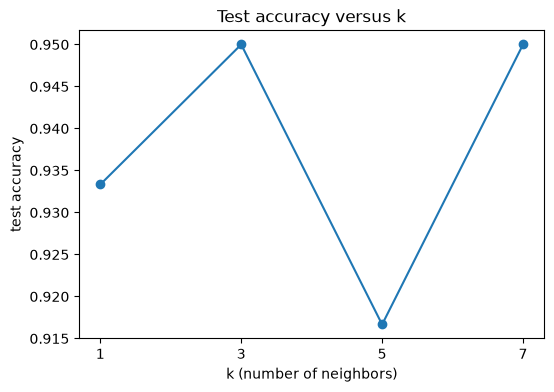

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, accuracies, marker='o')
ax.set_xticks(k_values)
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('test accuracy')
ax.set_title('Test accuracy versus k')
plt.show()

## Decision regions for a selected k

To picture what the classifier does, we shade the predicted class across a dense
grid for one chosen value of $k$, then overlay the training points colored by
their true label. The boundary is piecewise and follows the local arrangement of
points rather than a single straight line.

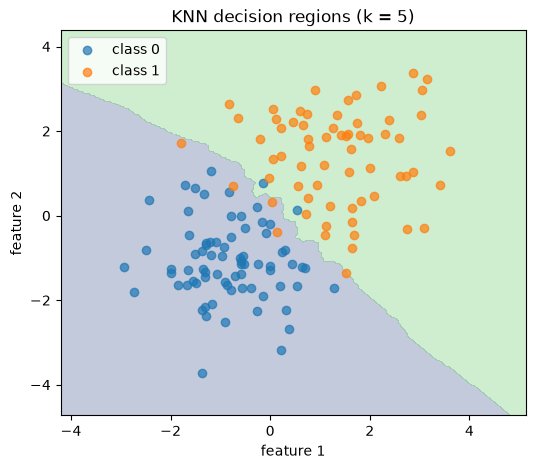

In [7]:
selected_k = 5
clf = KNNClassifier(k=selected_k).fit(X_train, y_train)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = clf.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.3, levels=1)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           label='class 0', alpha=0.7)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           label='class 1', alpha=0.7)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title(f'KNN decision regions (k = {selected_k})')
ax.legend()
plt.show()

## Interpretation

The accuracy-versus-$k$ plot shows how the choice of $k$ trades off sensitivity
to individual points against smoothing. The decision-region plot makes the
instance-based nature concrete: the boundary bends around the local data instead
of being a single line.

## Effect of k, scaling, cost, and noise

- **Effect of $k$.** Small $k$ (especially $k = 1$) follows the training data
  closely and is sensitive to noise, giving a jagged boundary that can overfit.
  Large $k$ averages over more neighbors, producing a smoother boundary, but if
  $k$ grows too large the prediction drifts toward the overall majority class
  and underfits.
- **Feature scaling.** Euclidean distance is dominated by features with large
  numeric ranges. If one feature spans 0–1000 and another 0–1, the first
  effectively decides every neighbor. Standardizing the features first puts them
  on equal footing — an important preprocessing step for KNN.
- **Computational cost.** Training is trivial, but each prediction compares the
  query against **every** stored point, so prediction cost grows with the size
  of the training set. This is the main drawback for large datasets; specialized
  data structures (such as KD-trees) can speed up the neighbor search.
- **Sensitivity to noisy points.** A mislabeled or outlier training point can
  flip predictions in its neighborhood, most severely when $k$ is small.
  Increasing $k$ reduces this sensitivity by requiring more agreement among
  neighbors.

## Next steps

Natural extensions include **standardizing the features** before fitting,
**distance-weighted voting** so closer neighbors count more, and **cross-
validation** to choose $k$ more reliably than a single train/test split.